# Nightlights around drug production areas

In [1]:
import pandas as pd
drug = pd.read_excel('../../data/drug_production/Captagon Factories -- All locations 2.xlsx', skiprows=1)

In [103]:
drug['Zone'].replace({'Rural Aleppo, Afrin, Al OqaibahAl Oqaibah, the eastern enterance of the village, Al Bassoutah road': 'Rural Aleppo, Afrin, Al Oqaibah'}, inplace=True)

In [2]:
drug['Factory_size'].replace({'large':'Large'}, inplace=True)

/var/folders/gs/_227cnyd0pq1fr817_0jbcyw0000gp/T/ipykernel_7327/737705068.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  drug['Factory_size'].replace({'large':'Large'}, inplace=True)


In [3]:
exact_locations = list(drug[drug['Yes_No'].isin(['Yes'])]['Zone'])
medium_factories = list(drug[drug['Factory_size'].isin(['Medium'])]['Zone'])
large_factories = list(drug[drug['Factory_size'].isin(['Large'])]['Zone'])

In [4]:
def get_buffer(zone):
    if zone in exact_locations and zone in medium_factories:
        return 1000
    elif zone in exact_locations and zone in large_factories:
        return 1000
    elif zone not in exact_locations:
        return 5000

In [5]:
drug['buffer_radius'] = drug['Zone'].apply(lambda x: get_buffer(x))

In [ ]:
import pandas as pd
import geopandas as gpd

# Example: column name is "coords" and values look like "36.289023, 37.242741\t"
clean = (
    drug["Coordinates"]
    .astype(str)
    .str.replace("\t", "", regex=False)
    .str.strip()
)

# If your format is: "lat, lon"
drug[["lat", "lon"]] = clean.str.split(",", n=1, expand=True).apply(lambda s: s.str.strip()).astype(float)

# Point(x, y) = Point(lon, lat)
gdf = gpd.GeoDataFrame(
    drug,
    geometry=gpd.points_from_xy(drug["lon"], drug["lat"]),
    crs="EPSG:4326"
)

# Buffer in projected CRS, then convert buffered geometry back to EPSG:4326
utm_crs = gdf.estimate_utm_crs()
gdf_utm = gdf.to_crs(utm_crs)
gdf_utm["buffer"] = gdf_utm.geometry.buffer(gdf_utm["buffer_radius"])

gdf_buffer = gdf_utm.set_geometry("buffer").copy()
gdf_buffer = gdf_buffer.to_crs(epsg=4326)
gdf_buffer = gdf_buffer.set_geometry("buffer").rename_geometry("geometry")

In [7]:
# gdf_5km = gdf_buffer_5km[["Zone", 'Address','Factory_size','Yes_No',"buffer_5km"]]
# gdf_10km = gdf_buffer_10km[["Zone", 'Address','Factory_size','Yes_No',"buffer_10km"]]

# # Ensure geometry is the 10km buffer polygon
# gdf_10km = gdf_10km.set_geometry('buffer_10km').copy()
# gdf_10km.reset_index(drop=True, inplace=True)

# Use spatial index to check overlaps: whether each buffer intersects any other buffer
sidx = gdf_buffer.sindex
overlaps = []
for i, geom in enumerate(gdf_buffer.geometry):
    # find candidates whose bbox intersects this geometry's bbox
    possible = list(sidx.intersection(geom.bounds))
    # exclude self
    possible = [j for j in possible if j != i]
    found = False
    for j in possible:
        if geom.intersects(gdf_buffer.geometry.iloc[j]):
            found = True
            break
    overlaps.append(found)
gdf_buffer['overlaps_any'] = overlaps

n_overlapping = int(gdf_buffer['overlaps_any'].sum())
total = len(gdf_buffer)
print(f"{n_overlapping} of {total} buffers overlap at least one other buffer.")

# Show list of overlapping zones (if any)
overlapping_zones = gdf_buffer.loc[gdf_buffer['overlaps_any'], 'Zone'].tolist()
print('Zones with overlaps:', overlapping_zones)

0 of 53 buffers overlap at least one other buffer.
Zones with overlaps: []


In [118]:
import geopandas as gpd
syria_adm0 = gpd.read_file('../../data/boundaries/syr_admin0.shp')
syria_adm1 = gpd.read_file('../../data/boundaries/syr_admin1.shp')

## Buffers around Factories

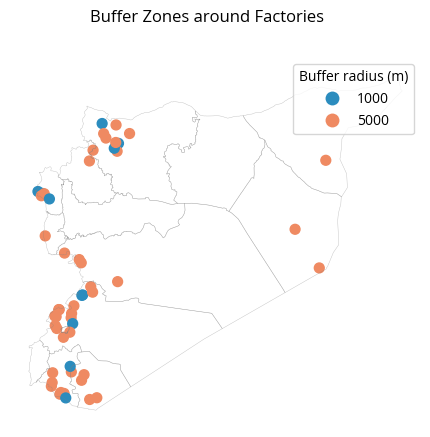

In [145]:
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, ax = plt.subplots()

plot_df = gdf_buffer.copy()
plot_df['buffer_radius_cat'] = plot_df['buffer_radius'].map({1000: '1000', 5000: '5000'})

# markersize applies to point geometries, so plot centroids instead of polygons
utm_crs = plot_df.estimate_utm_crs()
plot_points = plot_df.to_crs(utm_crs).copy()
plot_points = plot_points.set_geometry(plot_points.geometry.centroid).to_crs(plot_df.crs)

two_color_cmap = mpl.colors.ListedColormap(['#2b8cbe', '#ef8a62'])
plot_points.plot(
    column='buffer_radius_cat',
    categorical=True,
    markersize=50,
    cmap=two_color_cmap,
    legend=True,
    legend_kwds={'title': 'Buffer radius (m)'},
    ax=ax,
)

syria_adm1.boundary.plot(ax=ax, edgecolor='grey', alpha=0.5, linewidth=0.3)
plt.suptitle('Buffer Zones around Factories')
ax.set_axis_off()

In [9]:
import os
from pathlib import Path
from getpass import getpass
from dotenv import dotenv_values
from blackmarble import BlackMarble, Product

secrets_path = Path.home() / ".config" / "syria-economic-monitor" / "secrets.env"
secrets = dotenv_values(secrets_path)
blackmarble_token = secrets.get("BLACKMARBLE_TOKEN", "").strip()

if not blackmarble_token:
    blackmarble_token = getpass("Enter BlackMarble token (input hidden): ").strip()
    secrets_path.parent.mkdir(parents=True, exist_ok=True)
    secrets_path.write_text(f"BLACKMARBLE_TOKEN={blackmarble_token}\n")
    os.chmod(secrets_path, 0o600)

bm = BlackMarble(token=blackmarble_token)

In [23]:
from blackmarble import raster, extract

In [32]:
gdf_utm["buffer"] = gdf_utm.geometry.buffer(gdf_utm["buffer_radius"])
gdf_buffer = gdf_utm.set_geometry("buffer").copy()
gdf_buffer = gdf_buffer.to_crs(epsg=4326)
#gdf_buffer = gdf_buffer.set_geometry("buffer").rename_geometry("geometry")

In [33]:
monthly_drug_5km = extract.bm_extract(
    gdf_buffer,
    "VNP46A3",
pd.date_range("2023-01-01", "2026-01-01", freq="MS"),
token = blackmarble_token,
output_directory='../../data/ntl/raw/')

OBTAINING MANIFEST...:   0%|          | 0/2 [00:00<?, ?it/s]

QUEUEING TASKS | Downloading (8.7 GB)...:   0%|          | 0/74 [00:00<?, ?file/s]

PROCESSING TASKS | Downloading (8.7 GB)...:   0%|          | 0/74 [00:00<?, ?file/s]

COLLECTING RESULTS | Downloading (8.7 GB)...:   0%|          | 0/74 [00:00<?, ?file/s]

COLLATING TILES | Processing...:   0%|          | 0/37 [00:00<?, ?date/s]

In [21]:
import pandas as pd
for time_val in monthly_drug_5km['time'].values:
    date_str = pd.Timestamp(time_val).strftime('%Y-%m')
    monthly_drug_5km.sel(time=time_val)['NearNadir_Composite_Snow_Free'].rio.to_raster(
        f'../../data/ntl/raw/monthly_raster_{date_str}.tif'
    )

In [35]:
monthly_drug_5km.to_csv("../../data/ntl/drug_production_custom_buffer.csv", index=False)

In [37]:
baseline = monthly_drug_5km[monthly_drug_5km["date"] =='2024-11-01']
baseline = baseline[['Zone', 'ntl_sum']].set_index('Zone').to_dict()['ntl_sum']


In [79]:
monthly_drug_5km['baseline_ntl_sum'] = monthly_drug_5km['Zone'].map(baseline)
monthly_drug_5km['pc_change_baseline'] = 100*(monthly_drug_5km['ntl_sum'] - monthly_drug_5km['baseline_ntl_sum'])/(monthly_drug_5km['baseline_ntl_sum']+1)

In [111]:
monthly_drug_5km['Zone'].replace({'Rural Aleppo, Afrin, Al OqaibahAl Oqaibah, the eastern enterance of the village, Al Bassoutah road': 'Rural Aleppo, Afrin, Al Oqaibah'}, inplace=True)

/var/folders/gs/_227cnyd0pq1fr817_0jbcyw0000gp/T/ipykernel_7327/3509785299.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  monthly_drug_5km['Zone'].replace({'Rural Aleppo, Afrin, Al OqaibahAl Oqaibah, the eastern enterance of the village, Al Bassoutah road': 'Rural Aleppo, Afrin, Al Oqaibah'}, inplace=True)


## Average Nightlights in Factories

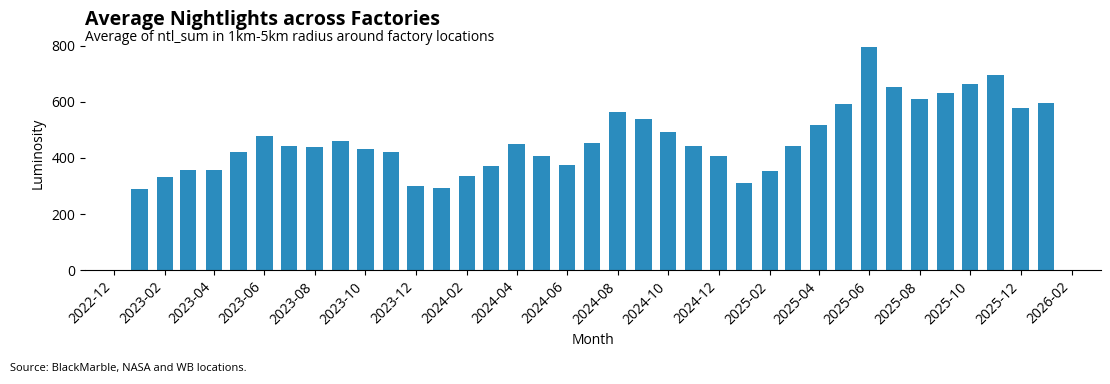

In [113]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import pandas as pd

# prepare aggregated series
if 'monthly_drug_5km_agg' not in globals():
    monthly_drug_5km_agg = monthly_drug_5km.groupby('date')["ntl_sum"].mean().reset_index()

# Try to use Open Sans if available, otherwise fall back to a sensible sans
font_family = "Open Sans"
available = {f.name for f in fm.fontManager.ttflist}
if font_family in available:
    plt.rcParams['font.family'] = font_family
else:
    plt.rcParams['font.family'] = ['Open Sans', 'DejaVu Sans', 'sans-serif']

def bar_plot(ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(11,4))
    else:
        fig = ax.figure

    ax.bar(monthly_drug_5km_agg['date'], monthly_drug_5km_agg['ntl_sum'], label='NTL', color='#2b8cbe', width=20)

    ax.set_ylabel('Luminosity')
    ax.set_xlabel('Month')

    # Hide top and left box lines
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Left-aligned title
    ax.set_title('Average Nightlights across Factories', fontsize=14, weight='bold', loc='left', pad=8)

    # Subtitle placed just below the title (left-aligned)
    ax.text(
        0,
        0.96,
        'Average of ntl_sum in 1km-5km radius around factory locations',
        transform=ax.transAxes,
        fontsize=10,
        va='bottom',
        ha='left'
    )

    # Source/note at the bottom-right
    fig.text(0.21, 0.01, 'Source: BlackMarble, NASA and WB locations.', ha='right', fontsize=8)

    # Format x-axis for monthly ticks
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    return fig, ax

# draw
fig, ax = bar_plot()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(False)
plt.show()


In [114]:
months_of_interest = ['2023-12-01', '2023-06-01', '2023-11-01', '2025-01-01', '2025-06-01', '2025-12-01']
monthly_drug_5km_moi = monthly_drug_5km[monthly_drug_5km['date'].isin(months_of_interest)]

/var/folders/gs/_227cnyd0pq1fr817_0jbcyw0000gp/T/ipykernel_7327/3569026627.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  monthly_drug_5km_moi = monthly_drug_5km[monthly_drug_5km['date'].isin(months_of_interest)]


## % Change in Nightlights in each factory compared to Nov 2024

In [161]:
monthly_drug_5km_moi = monthly_drug_5km_moi[
    ~(
        (monthly_drug_5km_moi['Zone'] == 'Rural Damascus, Falita') &
        (monthly_drug_5km_moi['Yes_No'].astype(str).str.strip().str.lower() != 'yes')
    )
].copy()

monthly_drug_5km_moi = monthly_drug_5km_moi[
    ~(
        (monthly_drug_5km_moi['Zone'] == 'Rural Damascus, Sarghayah') &
        (monthly_drug_5km_moi['Yes_No'].astype(str).str.strip().str.lower() != 'yes')
    )
].copy()

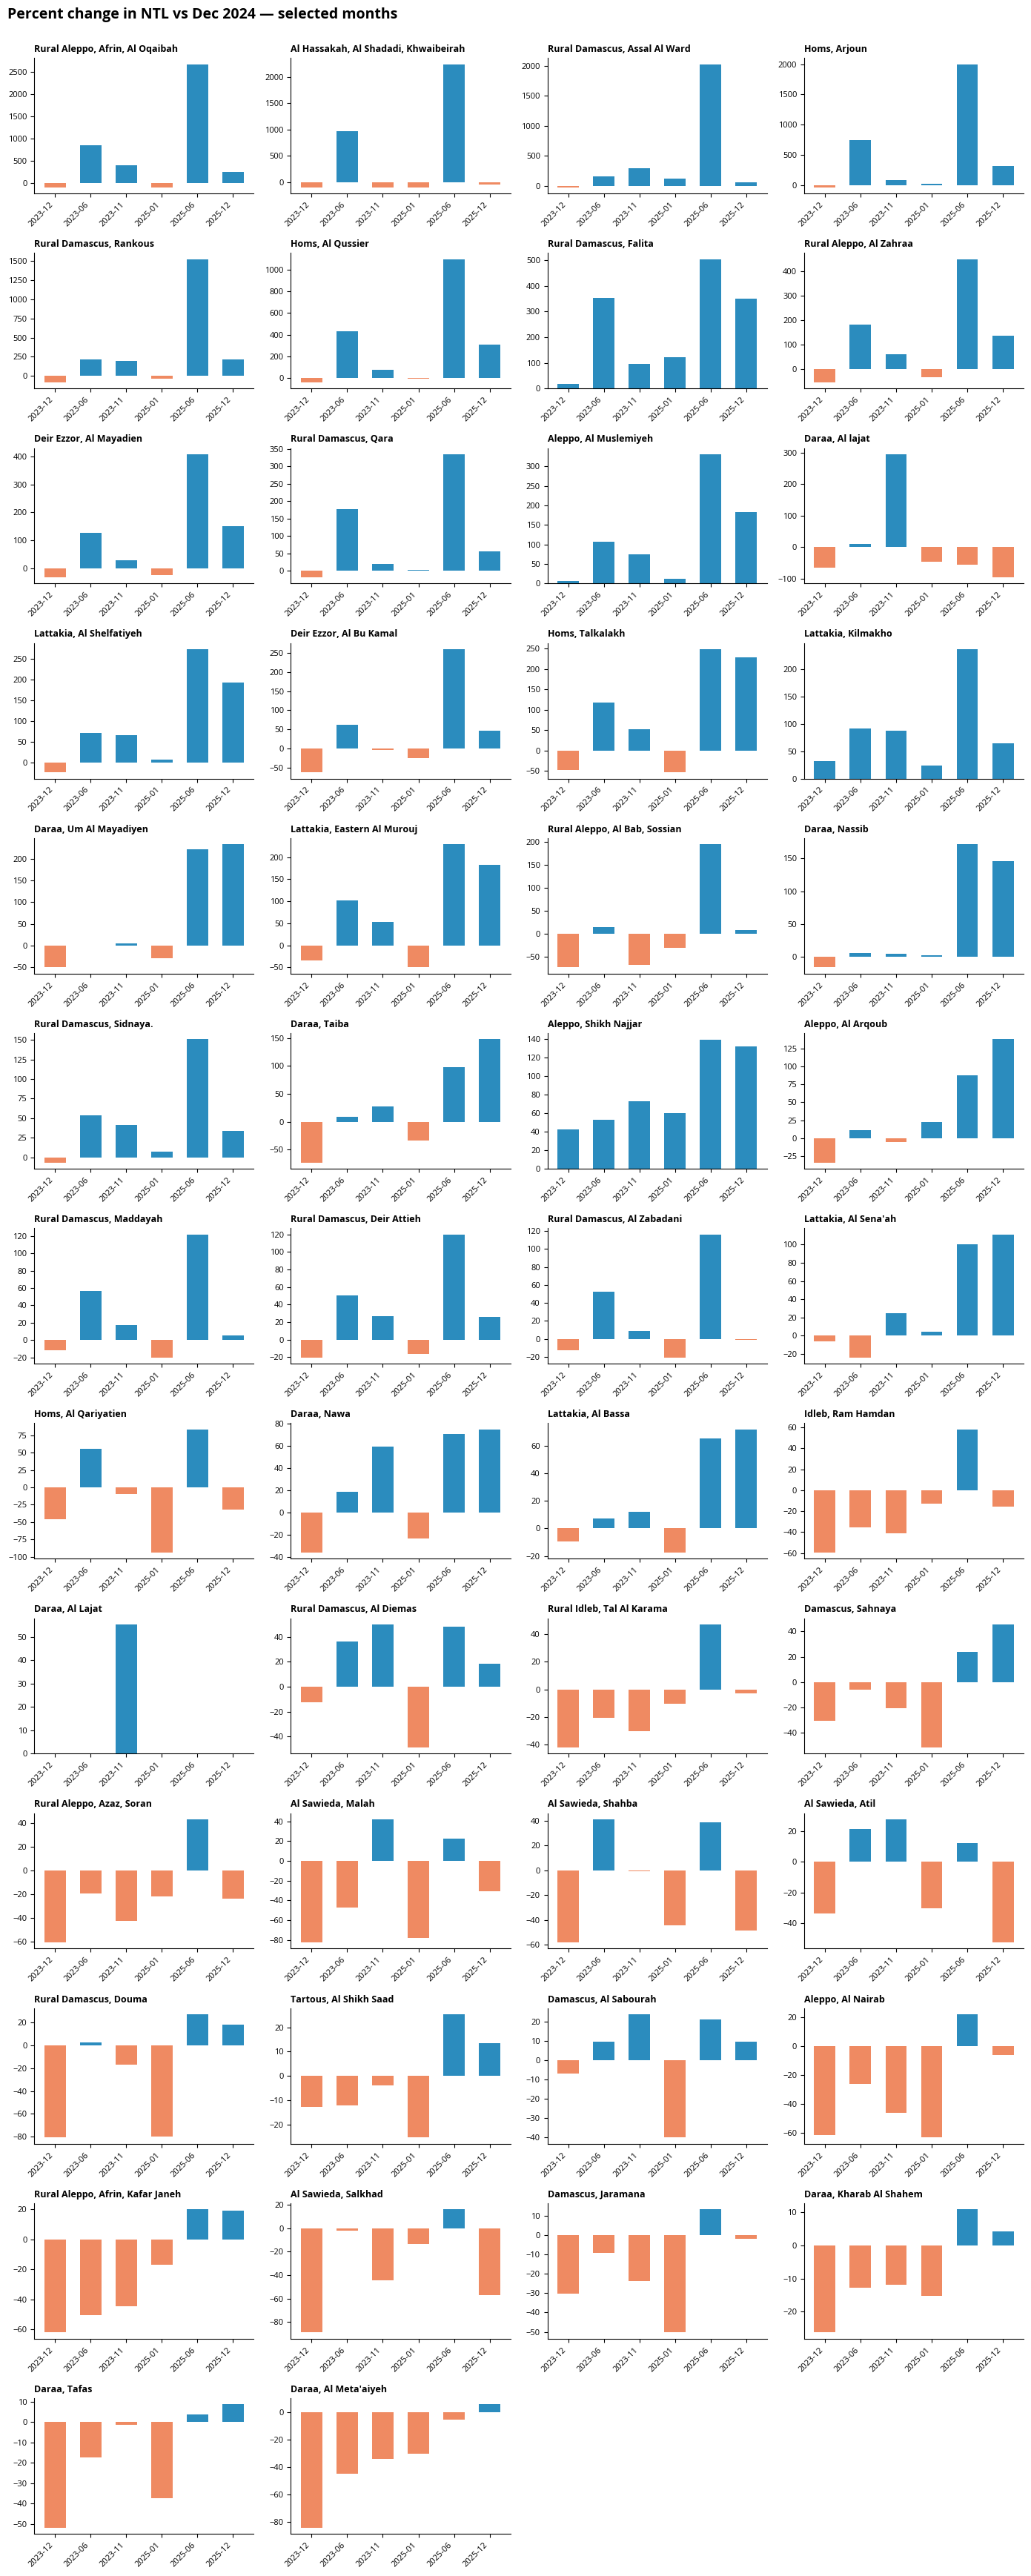

In [162]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd

# months of interest (categorical positions)
months_of_interest = ['2023-12-01', '2023-06-01', '2023-11-01', '2025-01-01', '2025-06-01', '2025-12-01']
months_dt = pd.to_datetime(months_of_interest)
months_labels = [d.strftime('%Y-%m') for d in months_dt]
positions = np.arange(len(months_dt))
pos_map = {pd.Timestamp(d): i for i, d in enumerate(months_dt)}

# ensure filtered table exists
if 'monthly_drug_5km_moi' not in globals():
    monthly_drug_5km_moi = monthly_drug_5km[monthly_drug_5km['date'].isin(months_dt)]

change_col = 'pc_change_baseline'

# Sort zones in descending order by their maximum change
zone_max = (
    monthly_drug_5km_moi.groupby('Zone')[change_col]
    .max()
    .sort_values(ascending=False)
)
zones = zone_max.index.tolist()
if not zones:
    raise RuntimeError('No zones found in monthly_drug_5km_moi.')

n_zones = len(zones)
cols = 4
rows = int(np.ceil(n_zones / cols))

# font: try Open Sans then fallback
font_family = 'Open Sans'
available = {f.name for f in fm.fontManager.ttflist}
if font_family in available:
    title_fp = fm.FontProperties(family=font_family, weight='bold', size=14)
    label_fp = fm.FontProperties(family=font_family, weight='bold', size=9)
    tick_labelsize = 8
else:
    title_fp = fm.FontProperties(family='DejaVu Sans', weight='bold', size=14)
    label_fp = fm.FontProperties(family='DejaVu Sans', weight='bold', size=9)
    tick_labelsize = 8

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.0), sharex=False, sharey=False)
axs = axes.flatten() if hasattr(axes, 'flatten') else [axes]

bar_width = 0.6

for idx, zone in enumerate(zones):
    ax = axs[idx]
    df = monthly_drug_5km_moi[monthly_drug_5km_moi['Zone'] == zone].copy()

    # always set x-ticks to the categorical months_of_interest
    ax.set_xticks(positions)
    ax.set_xticklabels(months_labels, rotation=45, ha='right', fontsize=tick_labelsize)

    if df.empty:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center', fontsize=9)
        ax.set_title(str(zone), fontproperties=label_fp, loc='left')
        continue

    # map each row's date to the categorical position
    df['pos'] = df['date'].map(lambda d: pos_map.get(pd.Timestamp(d)))
    df = df.dropna(subset=['pos'])

    # color positives vs negatives
    colors = ['#2b8cbe' if v >= 0 else '#ef8a62' for v in df[change_col]]

    ax.bar(df['pos'], df[change_col], width=bar_width, color=colors, align='center')
    ax.set_title(str(zone), fontproperties=label_fp, loc='left')
    ax.tick_params(axis='y', labelsize=tick_labelsize)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)
    ax.set_facecolor('#ffffff')

# Hide any unused subplots
for j in range(n_zones, len(axs)):
    axs[j].set_visible(False)

# main title
fig.suptitle('Percent change in NTL vs Dec 2024 — selected months', x=0.01, y=0.92, ha='left', fontsize=14, fontproperties=title_fp)
plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()


## Map of % change in NTL

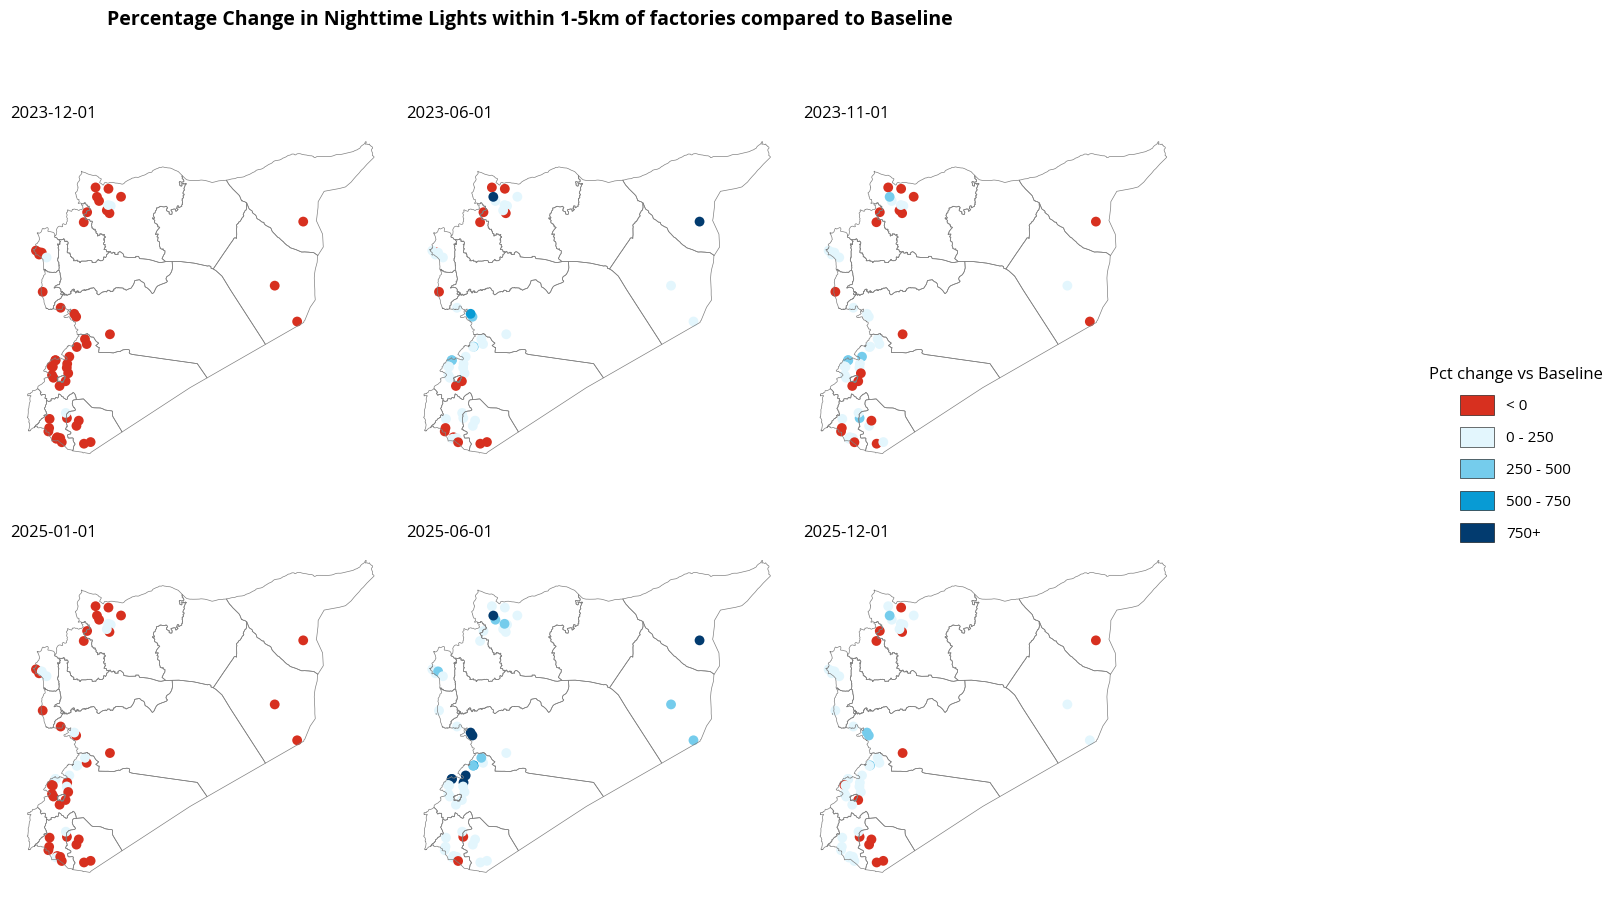

In [143]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib.patches import Patch

fig, ax = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(14, 10))
axs = ax.flatten()

# Fixed class breaks: <0, 0-250, 250-500, 500-750, 750+
vals = monthly_drug_5km_moi['pc_change_baseline'].dropna()
vmin = vals.min()
vmax = vals.max()
lower = min(vmin, -1e-6)
upper = max(vmax, 750 + 1e-6)
bins = np.array([lower, 0, 250, 500, 750, upper], dtype=float)

# 5 discrete colors: red for negatives + blue palette for positives
colors = [
    '#d7301f',  # <0
    '#E3F6FD',  # 0-250
    '#75CCEC',  # 250-500
    '#089BD4',  # 500-750
    '#023B6F',  # 750+
]
cmap = mpl.colors.ListedColormap(colors)
norm = mpl.colors.BoundaryNorm(bins, ncolors=cmap.N, clip=True)

for idx, month in enumerate(months_of_interest):
    subset = monthly_drug_5km_moi[monthly_drug_5km_moi['date'] == month].copy()

    # Keep factory areas visible as faint polygons
    subset.plot(
        column='pc_change_baseline',
        legend=False,
        ax=axs[idx],
        cmap=cmap,
        norm=norm,
        alpha=0.25,
        linewidth=0,
    )

    # Compute centroids in projected CRS to avoid geographic-CRS centroid warnings
    utm_crs = subset.estimate_utm_crs()
    subset_utm = subset.to_crs(utm_crs)
    subset_centroids = subset_utm.copy()
    subset_centroids = subset_centroids.set_geometry(subset_utm.geometry.centroid).to_crs(subset.crs)

    subset_centroids.plot(
        column='pc_change_baseline',
        legend=False,
        ax=axs[idx],
        cmap=cmap,
        norm=norm,
        markersize=50,
        edgecolor='none',
        linewidth=0,
    )

    syria_adm1.boundary.plot(ax=axs[idx], color='grey', linewidth=0.5)
    axs[idx].set_title(month, loc='left')
    axs[idx].grid(False)
    axs[idx].set_axis_off()

# Figure-level legend outside subplots (right side)
legend_labels = ['< 0', '0 - 250', '250 - 500', '500 - 750', '750+']
legend_handles = [
    Patch(facecolor=colors[i], edgecolor='black', linewidth=0.4, label=legend_labels[i])
    for i in range(len(colors))
]

fig.legend(
    handles=legend_handles,
    title='Pct change vs Baseline',
    loc='center left',
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
    fontsize=11,
    title_fontsize=12,
    handlelength=2.2,
    handleheight=1.6,
    borderpad=0.8,
    labelspacing=0.8,
)

fig.suptitle('Percentage Change in Nighttime Lights within 1-5km of factories compared to Baseline', x=0.08, y=0.945, ha='left', fontsize=14, fontproperties=title_fp)
plt.tight_layout(rect=[0, 0, 0.86, 0.93]);
